Describing Data. 

This Data is a combination was gathered from diffrent Data soucres. This Data is a combination of Data from USDA NASS and FRED


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ohio_clinton_df = pd.read_csv("/workspaces/INTRODUCTION-TO-Business_stats/Data_Analysis_Statistics/clinton_unemployment_snap_corn_df.csv")
ohio_clinton_df.tail()

,Observation_Date_Monthly,Unemployment_Rate_Clinton,Number_Of_Snap_Recipients_Clinton,Clinton_Corn_Grain_Yield_BU/ACRE,Clinton_Population_In_Thousands
277,February 2024,4.5,5075.347826,149.2,42.019
278,March 2024,4.3,5075.347826,149.2,42.019
279,April 2024,4.0,5075.347826,149.2,42.019
280,May 2024,3.9,5075.347826,149.2,42.019
281,June 2024,4.5,5075.347826,149.2,42.019


Measures of central tendecy

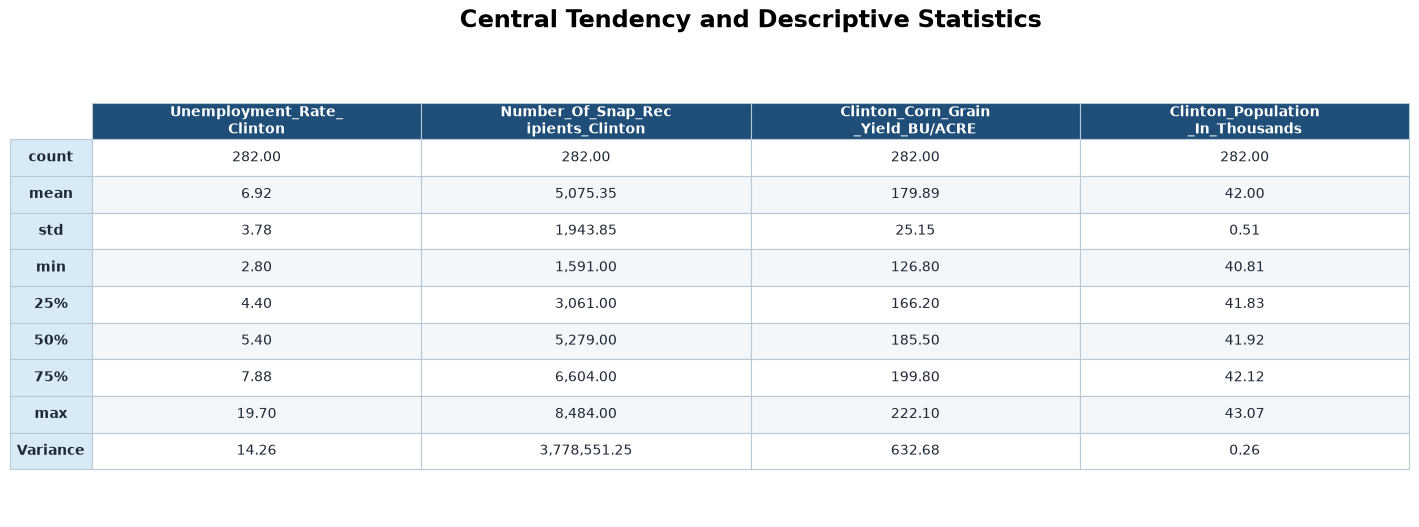

In [17]:
central_tendecy_summary = ohio_clinton_df.loc[:, "Unemployment_Rate_Clinton": "Clinton_Population_In_Thousands"].describe()
central_tendecy_summary_more = pd.DataFrame(central_tendecy_summary)
central_tendecy_summary_more.loc["Variance"] = central_tendecy_summary_more.loc['std', :] ** 2
import textwrap

# Copy your existing DataFrame
summary = central_tendecy_summary_more.copy()
# Wrap long column names
wrapped_columns = [
    "\n".join(textwrap.wrap(str(col), width=18))
    for col in summary.columns
]

# Round numbers for presentation
display_values = summary.copy()

for col in display_values.columns:
    display_values[col] = display_values[col].map(
        lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else str(x)
    )

# Make the figure WIDE
fig, ax = plt.subplots(figsize=(17, 6))
ax.axis("off")

# Create table
table = ax.table(
    cellText=display_values.values,
    colLabels=wrapped_columns,
    rowLabels=display_values.index,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

# Font and spacing
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Colors
header_color = "#1F4E78"
row_label_color = "#D9EAF7"
stripe_color = "#F3F7FA"
white = "#FFFFFF"
edge_color = "#B7C9D6"

# Style the cells
for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor(edge_color)
    cell.set_linewidth(0.8)

    # Header
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Row names: count, mean, std, etc.
    elif col == -1:
        cell.set_facecolor(row_label_color)
        cell.set_text_props(
            weight="bold",
            color="#1F2937"
        )

    # Alternate row colors
    else:
        if row % 2 == 0:
            cell.set_facecolor(stripe_color)
        else:
            cell.set_facecolor(white)

        cell.set_text_props(color="#1F2937")

# Title
plt.title(
    "Central Tendency and Descriptive Statistics",
    fontsize=17,
    fontweight="bold",
    pad=20
)

# Save high-resolution version for PowerPoint
plt.savefig(
    "central_tendency_summary_presentation.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Boxplot

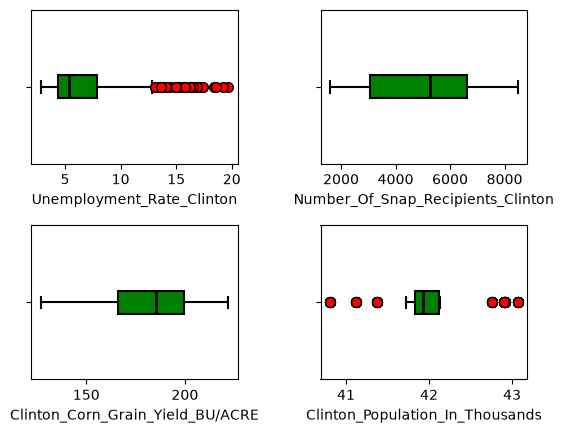

In [50]:
int_variables = ohio_clinton_df.loc[:, "Unemployment_Rate_Clinton": "Clinton_Population_In_Thousands"]
fig1, axes1 = plt.subplots(nrows= 2, ncols= 2)
for variable_name, axess in zip(int_variables, axes1.flat):
    box = axess.boxplot(
        int_variables[variable_name],
        orientation="horizontal",
        patch_artist=True,
        boxprops=dict(
            facecolor="green",  # Color inside the box
            color="black",       # Outline color of the box
            linewidth=1.5
        ),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor="red",
            markersize=7
        )
    )

    axess.set_xlabel(variable_name)
    axess.set_yticklabels([])
fig1.subplots_adjust(wspace=0.4, hspace=0.4)
plt.savefig(
    "scatter_plots.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)   

Histogram

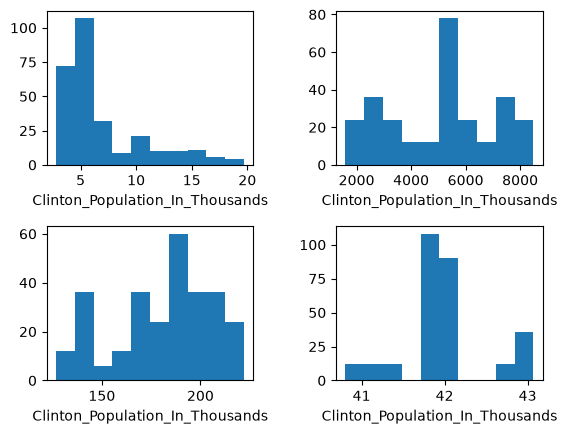

In [53]:
fig2, axes2 = plt.subplots(nrows=2, ncols=2)
for varname, axes2g in zip(int_variables, axes2.flat):
    axes2g.hist(int_variables[varname])
    axes2g.set_xlabel(variable_name)
fig2.subplots_adjust(wspace=0.4, hspace=0.4)

Correlations